<center>
<center>
<h4>MECH564, Fundamentals of Robot Mechanics and Control</h4>
<font><h2>Lab2: Forward Position and Velocity Kinematics</h2></font>
<h4>Colorado State University</h4>
</center>

---

**Introduction:**

In this lab, we will practice solving forward position and velocity kinematics using both analytical approaches discussed in lectures and MuJoCo physics simulation. The analytical approach is based on the **Product of Exponentials (POE)** formulation and **screw theory**. We will implement POE-based forward kinematics for several robotic arms (3R and SO-ARM 101), validate our results against MuJoCo's kinematics engine, and learn to compute the **Jacobian matrix** using the screw-based method. Finally, we will visualize robot motions and compare analytical and simulation-based results.

**Learning Objectives:**
- Apply the **Product of Exponentials (POE)** formula to compute forward kinematics for serial chain manipulators
- Use **MuJoCo** as a kinematics engine to validate analytical models
- Build and simulate robotic arm models in MuJoCo from MJCF/XML descriptions, which can be derived from Universal Robot Description File (URDF).
- Compute the **space Jacobian** using the screw-based approach with adjoint transformations
- Compare analytical and numerical methods for forward position and velocity kinematics
- Work with real robot models (SO-ARM 101, UR5e) from open-source repositories

In [9]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
#import math

""""""
# Set up matplotlib for inline plotting,
# "%" is Jupyter magic command:
# a special command that provides convenient shortcuts for common operations.
# it is not a standard part of Python, but only for Jupyter notebooks,
# which is how this lab is written with
""""""
%matplotlib inline

## Task 0: Matrix Exponential for Rotation and Homogeneous Transformation Matrices

We include the functions we developed in lab 1 for matrix exponentials for rotation and homogeneous transformation matrices again, as we need to use them for the POE formula for forward kinematics.   

#### 1. Matrix Exponential for Rotation Matrices

For a 3×3 rotation matrix **R**, we can use the exponential map to generate rotations from a skew-symmetric matrix (rotation vector):

- **Exponential Map**: from $so(3)$ to $SO(3)$, which can be obtained by $\mathbf{R} = \exp([\hat{\boldsymbol{\omega}}]\theta) = \mathbf{I} + \sin\theta[\hat{\boldsymbol{\omega}}] + (1-\cos\theta)[\hat{\boldsymbol{\omega}}]^2$
  - **Input**: Skew-symmetric matrix from unit rotation axis $\hat{\boldsymbol{\omega}}$ with rotation angle $\theta$
  - **Output**: Three by three Rotation matrix **R**

In [10]:
import numpy as np
# Helper function: Create skew-symmetric matrix from a 3D vector
def skew_symmetric(omega):
    """
    Create a 3x3 skew-symmetric matrix from a 3D vector.

    For a vector omega = [w1, w2, w3], creates:
    [omega] = [  0  -w3   w2]
              [ w3    0  -w1]
              [-w2   w1    0]

    Parameters:
    omega: 3D vector (numpy array or list)

    Returns:
    3x3 skew-symmetric matrix (numpy array)
    """
    omega = np.array(omega).flatten()
    if len(omega) != 3:
        raise ValueError("Input must be a 3D vector")

    return np.array([
        [0,         -omega[2],  omega[1]],
        [omega[2],   0,        -omega[0]],
        [-omega[1],  omega[0],  0]
    ])


def matrix_exp_so3(omega_hat_skew, theta):
    """
    Exponential map from so(3) to SO(3) using Rodrigues' formula.

    Computes: R = exp([omega_hat]*theta) = I + sin(theta)*[omega_hat] + (1-cos(theta))*[omega_hat]^2

    Parameters:
    omega_hat_skew: 3x3 skew-symmetric matrix of UNIT rotation axis (numpy array)
    theta: rotation angle in radians (scalar)

    Returns:
    R: 3x3 rotation matrix in SO(3)

    Example:
    >>> omega_hat = np.array([0, 0, 1])  # Unit vector along z-axis
    >>> omega_hat_skew = skew_symmetric(omega_hat)
    >>> R = matrix_exp_so3(omega_hat_skew, np.pi/2)  # 90 degree rotation about z
    """
    # Verify input is 3x3
    if omega_hat_skew.shape != (3, 3):
        raise ValueError("Input must be a 3x3 skew-symmetric matrix")

    # Check if matrix is skew-symmetric (within numerical tolerance)
    if not np.allclose(omega_hat_skew, -omega_hat_skew.T):
        raise ValueError("Input matrix must be skew-symmetric: [omega]^T = -[omega]")

    # Identity matrix
    I = np.eye(3)

    # Apply Rodrigues' formula
    # R = I + sin(theta)*[omega_hat] + (1-cos(theta))*[omega_hat]^2
    R = I + np.sin(theta) * omega_hat_skew + (1 - np.cos(theta)) * (omega_hat_skew @ omega_hat_skew)

    return R


def matrix_exp_so3_from_vector(omega_theta):
    """
    Exponential map from so(3) to SO(3) using exponential coordinates.

    This is a convenient wrapper that takes the rotation vector directly
    (where the magnitude is the angle and direction is the axis).

    Parameters:
    omega_theta: 3D rotation vector where ||omega_theta|| = theta (rotation angle)
                 and omega_theta/||omega_theta|| = omega_hat (unit rotation axis)

    Returns:
    R: 3x3 rotation matrix in SO(3)

    Example:
    >>> omega_theta = np.array([0, 0, np.pi/2])  # 90 deg rotation about z-axis
    >>> R = matrix_exp_so3_from_vector(omega_theta)
    """
    omega_theta = np.array(omega_theta).flatten()

    # Calculate rotation angle (magnitude of vector)
    theta = np.linalg.norm(omega_theta)

    # Handle special case: zero rotation
    if theta < 1e-10:
        return np.eye(3)

    # Extract unit rotation axis
    omega_hat = omega_theta / theta

    # Create skew-symmetric matrix
    omega_hat_skew = skew_symmetric(omega_hat)

    # Apply Rodrigues' formula
    return matrix_exp_so3(omega_hat_skew, theta)

def matrix_log_so3(R):
    """
    Logarithm map from SO(3) to so(3) using the algorithm from Modern Robotics textbook.

    Given R ∈ SO(3), find θ ∈ [0, π] and unit rotation axis ω ∈ ℝ³, ||ω|| = 1,
    such that R = exp([ω]θ).

    Algorithm:
    (a) If R = I, then θ = 0 and ω is undefined.
    (b) If tr(R) = -1, then θ = π. Use formula (3.60): ω = (1/√(2(1+r₁₁))) [1+r₁₁, r₂₁, r₃₁]ᵀ
    (c) Otherwise, θ = arccos((tr(R)-1)/2) and [ω] = (1/(2sinθ))(R - Rᵀ)

    Parameters:
    R: 3x3 rotation matrix (numpy array)

    Returns:
    omega_hat_skew: 3x3 skew-symmetric matrix [ω] = [ω]θ where ω is unit rotation axis
    theta: scalar rotation angle in radians
    omega_hat: 3D unit rotation axis vector (None if R=I)

    Example:
    >>> R = matrix_exp_so3_from_vector(np.array([0, 0, np.pi/2]))
    >>> omega_hat_skew, theta, omega_hat = matrix_log_so3(R)
    >>> print(f"Angle: {theta}, Axis: {omega_hat}")
    """

    # Verify input is 3x3
    if R.shape != (3, 3):
        raise ValueError("Input must be a 3x3 rotation matrix")

    # Verify it's a valid rotation matrix
    if not np.allclose(np.linalg.det(R), 1.0, atol=1e-6): #allclose checks if the determinant is close to 1 within a small tolerance
        raise ValueError(f"Input matrix determinant is {np.linalg.det(R):.6f}, not 1. Not a valid rotation matrix.")

    if not np.allclose(R @ R.T, np.eye(3), atol=1e-6):
        raise ValueError("Input matrix is not orthogonal (R @ R.T ≠ I). Not a valid rotation matrix.")

    # Case (a): If R = I, then θ = 0
    if np.allclose(R, np.eye(3), atol=1e-6):
        print("Case (a): R = I, so θ = 0 and ω is undefined")
        omega_hat_skew = np.zeros((3, 3))
        theta = 0.0
        omega_hat = None
        return omega_hat_skew, theta, omega_hat

    # Calculate trace of R, i.e., trace(r11 + r22 + r33)
    trace_R = np.trace(R)

    # Case (b): If tr(R) = -1, then θ = π
    if np.isclose(trace_R, -1.0, atol=1e-6):
        print("Case (b): tr(R) = -1, so θ = π")
        theta = np.pi

        # Use formula (3.60): ω = (1/√(2(1+r₁₁))) [1+r₁₁, r₂₁, r₃₁]ᵀ
        # where r₁₁ is R[0,0], r₂₁ is R[1,0], r₃₁ is R[2,0]
        r11 = R[0, 0]
        r21 = R[1, 0]
        r31 = R[2, 0]

        denominator = np.sqrt(2 * (1 + r11))

        if abs(denominator) < 1e-10:
            # Try formula (3.59) if (3.60) has numerical issues
            r12 = R[0, 1]
            r22 = R[1, 1]
            r32 = R[2, 1]
            denominator = np.sqrt(2 * (1 + r22))
            omega_hat = np.array([r12, 1 + r22, r32]) / denominator
        else:
            omega_hat = np.array([1 + r11, r21, r31]) / denominator

        omega_hat_skew = skew_symmetric(omega_hat)

        print(f"  Using formula (3.60): ω = {omega_hat}")
        return omega_hat_skew, theta, omega_hat

    # Case (c): Otherwise, use general formula
    print("Case (c): General case")

    # θ = arccos((tr(R) - 1) / 2)
    theta = np.arccos((trace_R - 1) / 2)

    # [ω] = (1/(2sinθ)) * (R - Rᵀ)
    sin_theta = np.sin(theta)

    if abs(sin_theta) < 1e-6:
        raise ValueError("sin(θ) is too close to zero. Numerical issue in logarithm computation.")

    omega_hat_skew = (1 / (2 * sin_theta)) * (R - R.T)

    # Extract ω from skew-symmetric matrix
    # For skew-symmetric matrix [ω] = [  0  -w3   w2]
    #                                 [ w3    0  -w1]
    #                                 [-w2   w1    0]
    # ω = [w1, w2, w3]
    omega_hat = np.array([omega_hat_skew[2, 1], omega_hat_skew[0, 2], omega_hat_skew[1, 0]])

    print(f"  θ = arccos((tr(R)-1)/2) = {theta:.6f} rad = {np.degrees(theta):.2f}°")
    print(f"  ω = {omega_hat}")

    return omega_hat_skew, theta, omega_hat

#### 2. Matrix Exponential for Homogeneous Transformation Matrices

We can perform the similar transformation for Homogeneous Transformation Matrices. Specifically, for SE(3) (Special Euclidean Group in 3D), a homogeneous transformation matrix combines rotation and translation:

$$\mathbf{T} = \begin{bmatrix} \mathbf{R}_{3\times3} & \mathbf{p}_{3\times1} \\ \mathbf{0}_{1\times3} & 1 \end{bmatrix}$$

- **Exponential Map**: $\mathbf{T} = \exp([\mathcal{S}]\theta)$ where $[\mathcal{S}]$ is a 4×4 matrix from the screw $\mathcal{S}=[\mathcal{S}_\omega, \mathcal{S}_v]$:
$$[\mathcal{S}] = \begin{bmatrix} [\mathcal{S}_\omega] & \mathcal{S}_v \\ \mathbf{0}_{1\times3} & 0 \end{bmatrix}$$

  - Input: $[\mathcal{S}]\theta$

  - Output: Homogeneous transformation **T**

In [11]:
def matrix_exp_se3(S, theta):
    """
    Exponential map from se(3) to SE(3) using screw axis formulation.

    Given screw axis S = [S_omega, S_v] and angle theta, compute:
    T = exp([S] theta) = [[R, p], [0, 1]]

    If ||S_omega|| = 0 (pure translation):
        R = I, p = S_v * theta
    Otherwise:
        R = exp([omega_hat] theta)
        p = (I*theta + (1-cos(theta))[omega_hat] + (theta - sin(theta))[omega_hat]^2) S_v

    Parameters:
    S: 6D screw axis array [S_omega (3,), S_v (3,)]
    theta: scalar joint displacement

    Returns:
    T: 4x4 homogeneous transformation matrix in SE(3)
    """
    S = np.array(S).flatten()
    if S.shape[0] != 6:
        raise ValueError("S must be a 6D vector: [S_omega, S_v]")

    S_omega = S[:3]
    S_v = S[3:]

    omega_norm = np.linalg.norm(S_omega)
    I = np.eye(3)

    if omega_norm < 1e-10:
        # Pure translation
        R = I
        p = S_v * theta
    else:
        # Rotation + translation
        omega_hat = S_omega / omega_norm
        omega_hat_skew = skew_symmetric(omega_hat)

        R = matrix_exp_so3(omega_hat_skew, theta)

        V = (
            I * theta
            + (1 - np.cos(theta)) * omega_hat_skew
            + (theta - np.sin(theta)) * (omega_hat_skew @ omega_hat_skew)
        )
        p = V @ S_v

    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = p

    return T

## Task 1: Forward Kinematics using Product of Exponential (POE)
### Task 1.1 Forward Kinematics for a 3R robot

We first implement the 3R robot in textbook (Example 4.1), for which we have already obtained the screw for each joint.

![image.png](attachment:image.png)

In [12]:
# Forward kinematics for the 3R arm via Product of Exponentials (L1 = L2 = 1)
L1 = L2 = 1.0

# Define screw axes for the 3R arm in the space frame (S_list) and the home configuration M
S_list = [
    np.array([0.0, 0.0, 1.0, 0.0,      0.0,   0.0]),      # Joint 1 screw axis
    np.array([0.0, -1.0, 0.0, 0.0,     0.0,  -L1]),       # Joint 2 screw axis
    np.array([1.0, 0.0, 0.0, 0.0,      -L2,   0.0]),       # Joint 3 screw axis
]

# Home configuration of the end-effector (M) when theta = [0, 0, 0]
M = np.array([
    [0.0, 0.0, 1.0, L1],
    [0.0, 1.0, 0.0, 0.0],
    [-1.0, 0.0, 0.0, -L2],
    [0.0, 0.0, 0.0, 1.0],
])


def forward_kinematics_poe(theta):
    """Return T(theta) using the POE formula e^[S1]theta1 e^[S2]theta2 e^[S3]theta3 M."""
    if len(theta) != 3:
        raise ValueError("theta must contain three joint angles [theta1, theta2, theta3].")

    T = np.eye(4) # Initialize T as the identity matrix
    for S_i, theta_i in zip(S_list, theta):
        T = T @ matrix_exp_se3(S_i, theta_i) # Update T by multiplying with the exponential of the current joint's screw axis and angle
    return T @ M


# Example: evaluate T(theta) for a sample configuration
theta_example = np.deg2rad([30, -45, 60])  # radians
T_example = forward_kinematics_poe(theta_example)
print("Homogeneous transform T(theta):")
print(np.round(T_example, 4))

Homogeneous transform T(theta):
[[-0.739  0.28   0.612  0.254]
 [ 0.573  0.739  0.354  0.146]
 [-0.354  0.612 -0.707 -0.707]
 [ 0.     0.     0.     1.   ]]


### Task 1.2 Forward Kinematics for SO-ARM 101

We next consider a more realistic example: the open-source **SO-ARM 101**, a low-cost, education-focused manipulator ([SO-ARM 101 repository](https://github.com/TheRobotStudio/SO-ARM100)). The arm is designed with a lightweight serial-link structure and **five actuated revolute joints** (shoulder pan, shoulder lift, elbow flex, wrist flex, wrist roll), giving a practical balance between reach, dexterity, and simplicity. Its mechanical and software design emphasizes accessibility: standardized link/joint definitions, URDF-based modeling, and compatibility with modern learning/control stacks such as [LeRobot](https://huggingface.co/docs/lerobot/index). This makes SO-ARM 101 a good platform for studying how real robot geometry maps into POE screw-axis kinematics.

![SO-ARM 101](https://maegantucker.com/ECE4560/assets/SO101_Follower.webp)

The geometric parameters are taken directly from the URDF joint specifications: each joint provides a fixed transform from the parent link to the child link as an **xyz** translation and **rpy** rotation, plus a joint axis expressed in the child frame. The code converts each `(xyz, rpy)` into a homogeneous transformation, then propagates link frames from `base_link` to obtain each joint frame in the space frame.

For each joint, the screw axis in the space frame is computed as **S = (ω, v)**, where **ω** is the joint axis rotated into the space frame and **v = −ω × q**, with **q** a point on the axis (the joint frame origin in the space frame). These screw axes are assembled as columns of the 6×5 matrix **S_list_SO101** for the five main joints. The home configuration **M_SO101** is the end‑effector (gripper_link) pose in the base frame when all joint angles are zero, obtained from the propagated frames. The following code prints the resulting **S_list_SO101** and **M_SO101** for direct use in POE forward kinematics.

In [5]:
# SO-ARM 101: space-frame screw axes and home configuration M
# We use the URDF dimensions (so101_new_calib.urdf) and treat the base_link
# frame as the space frame. All joint angles are zero at the home configuration.

import numpy as np

# Helper: roll–pitch–yaw (URDF convention) to rotation matrix
# R = Rz(yaw) * Ry(pitch) * Rx(roll)
def rpy_to_R(roll, pitch, yaw):
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)
    R = np.array([
        [cy * cp, cy * sp * sr - sy * cr, cy * sp * cr + sy * sr],
        [sy * cp, sy * sp * sr + cy * cr, sy * sp * cr - cy * sr],
        [-sp,     cp * sr,                cp * cr],
    ])
    return R


def T_from_xyz_rpy(xyz, rpy):
    R = rpy_to_R(*rpy)
    p = np.array(xyz, dtype=float)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = p
    return T


# Joint definitions taken from Test/SO-Arm 101/Simulation-SO101/so101_new_calib.urdf
# Each entry: (name, parent_link, child_link, xyz, rpy, axis_in_child)
joint_defs = [
    ("shoulder_pan",  "base_link",        "shoulder_link",   [0.0388353, -8.97657e-09, 0.0624],   [3.14159, 4.18253e-17, -3.14159], [0, 0, 1]),
    ("shoulder_lift", "shoulder_link",    "upper_arm_link",  [-0.0303992, -0.0182778, -0.0542],  [-1.5708, -1.5708, 0.0],          [0, 0, 1]),
    ("elbow_flex",    "upper_arm_link",   "lower_arm_link",  [-0.11257, -0.028, 1.73763e-16],    [-3.63608e-16, 8.74301e-16, 1.5708], [0, 0, 1]),
    ("wrist_flex",    "lower_arm_link",   "wrist_link",      [-0.1349, 0.0052, 3.62355e-17],     [4.02456e-15, 8.67362e-16, -1.5708], [0, 0, 1]),
    ("wrist_roll",    "wrist_link",       "gripper_link",    [5.55112e-17, -0.0611, 0.0181],     [1.5708, 0.0486795, 3.14159],    [0, 0, 1]),
    # Optional gripper joint (opening/closing)
    ("gripper",       "gripper_link",     "moving_jaw_so101_v1_link", [0.0202, 0.0188, -0.0234], [1.5708, -5.24284e-08, -1.41553e-15], [0, 0, 1]),
]

# Forward propagation of link frames at home (all joint angles = 0)
T_world = {"base_link": np.eye(4)}
S_list_SO101 = []  # space-frame screw axes for main 5 DOF

for name, parent, child, xyz, rpy, axis_local in joint_defs:
    T_parent_child = T_from_xyz_rpy(xyz, rpy) # transform from xyz+rpy to homogeneous transform matrix
    T_world_parent = T_world[parent] # transform from world frame to parent link frame at home configuration
    T_world_child = T_world_parent @ T_parent_child # transform from world frame to child link frame at home configuration
    T_world[child] = T_world_child # store transform from world frame to child link frame at home configuration

    # Joint axis and a point on the axis, both in space frame
    omega = T_world_child[:3, :3] @ np.array(axis_local, dtype=float)
    q = T_world_child[:3, 3]
    v = -np.cross(omega, q)
    S = np.hstack((omega, v))

    if name != "gripper":  # use first 5 joints for arm FK
        S_list_SO101.append(S)

# Home configuration of the end-effector frame (we use gripper_link as EE)
M_SO101 = T_world["gripper_link"]

S_list_SO101 = np.array(S_list_SO101).T  # 6x5 matrix [S1 S2 S3 S4 S5]

print("Space-frame screw axes S (columns S1..S5):")
print(np.round(S_list_SO101, 4))
print("\nHome configuration M (gripper_link in base frame at zero joint angles):")
print(np.round(M_SO101, 4))

Space-frame screw axes S (columns S1..S5):
[[-0.000e+00 -0.000e+00 -0.000e+00 -0.000e+00 -1.000e+00]
 [ 0.000e+00  1.000e+00  1.000e+00  1.000e+00 -0.000e+00]
 [-1.000e+00  0.000e+00  0.000e+00  0.000e+00 -0.000e+00]
 [-0.000e+00 -1.166e-01 -2.292e-01 -2.344e-01  0.000e+00]
 [ 3.880e-02 -0.000e+00 -0.000e+00 -0.000e+00 -2.344e-01]
 [ 0.000e+00  6.920e-02  9.720e-02  2.321e-01 -2.000e-04]]

Home configuration M (gripper_link in base frame at zero joint angles):
[[-0.000e+00 -0.000e+00 -1.000e+00  2.932e-01]
 [-4.870e-02  9.988e-01 -0.000e+00 -2.000e-04]
 [ 9.988e-01  4.870e-02 -0.000e+00  2.344e-01]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]


Using the obtained M and screw axis, we can now solve the forward position kinematics for the SO-Arm 101 using POE.

In [13]:
# Forward position kinematics for SO-ARM 101 using POE
# Uses space-frame screw axes S_list_SO101 (6x5) and home configuration M_SO101

import numpy as np

def fk_so101_poe(theta):
    """Compute end-effector pose T(θ) for SO-ARM 101 via Product of Exponentials.

    Parameters
    ----------
    theta : array_like, shape (5,)
        Joint angles [θ1, θ2, θ3, θ4, θ5] in radians for
        [shoulder_pan, shoulder_lift, elbow_flex, wrist_flex, wrist_roll].

    Returns
    -------
    T : ndarray, shape (4,4)
        Homogeneous transform of the gripper_link frame in the base frame.
    """
    theta = np.asarray(theta).flatten()
    if theta.size != 5:
        raise ValueError("theta must contain 5 joint angles: [θ1, θ2, θ3, θ4, θ5].")

    # Start from identity in space frame
    T = np.eye(4)

    # S_list_SO101 is 6x5 with columns S_i; multiply exp([S_i] θ_i) from left to right
    for i in range(5):
        S_i = S_list_SO101[:, i]
        T = T @ matrix_exp_se3(S_i, theta[i])

    # Multiply by home configuration
    return T @ M_SO101


# Example: test at a sample configuration (radians)
theta_test = np.deg2rad([10, 20, -30, 40, -15])
T_so101 = fk_so101_poe(theta_test)
print("SO-ARM 101 FK T(θ):")
print(np.round(T_so101, 4))

SO-ARM 101 FK T(θ):
[[ 0.416  0.316 -0.853  0.315]
 [-0.384  0.911  0.15  -0.049]
 [ 0.825  0.265  0.5    0.211]
 [ 0.     0.     0.     1.   ]]


## Task 2: Introduction to Mujoco

MuJoCo is a physics engine widely used for robotics simulation and control. It provides efficient computation of kinematics, dynamics, and collisions. In this lab, we use MuJoCo as a **kinematics engine** (without stepping through time, which is for the dynamics) to validate our analytical POE forward kinematics. You can find a introduction tutorial for Mujoco here: [Mujoco Tutorial](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/python/tutorial.ipynb).

In the cell below, we install MuJoCo and set up the necessary dependencies for GPU-accelerated rendering in Colab. Note that you will need to connect to a GPU in colab to make it work.

In [14]:
!pip install mujoco

# Set up GPU rendering.
from google.colab import files
import distutils.util
import os
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

# Check if installation was succesful.
try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Other imports and helper functions
import time
import itertools
import numpy as np

# Graphics and plotting.
print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()

### Task 2.1 Create the 3R robot arm in Mujoco

In this task, we will create a simple 3R arm that we investigated in Task 1 with L1 = L2 = 1. This demonstrates how to define a robot directly in MuJoCo's MJCF (XML) format. In practice, robot models are often designed in CAD software (e.g., SolidWorks, Fusion 360), exported as STL mesh files for visual/collision geometry, converted to URDF (Unified Robot Description Format) with link and joint definitions, and finally translated to MJCF using tools like the `compile` utility in MuJoCo or third-party converters. This workflow enables realistic geometry and inertial properties while maintaining compatibility across simulation platforms.

We will use the simple 3R robot to illustrate key MuJoCo concepts:
- **MjModel**: Represents the robot structure, including bodies, joints, sensors, and constraints, loaded from an MJCF (MuJoCo XML Format) file. You can consider it reprents all quantities which do not change over time.
- **MjData**: Holds the simulation state at a given instant—joint positions (`qpos`), velocities (`qvel`), body poses (`xpos`, `xmat`), and forces. As opposed to MjModel, it represents all quantities which change over time.
- **mj_forward()**: Computes forward kinematics: given joint angles in `data.qpos`, it propagates the kinematic chain to compute all body positions and rotations stored in `data.xpos` and `data.xmat`, respectively.
- **mj_name2id()**: Maps a body name (string) to its integer ID in the model for efficient access.

In [15]:
# MuJoCo model and forward kinematics for the 3R arm (L1 = L2 = 1)
L1 = L2 = 1.0

# MJCF description of the 3R arm.
# The joint screw axes match S_list from Task 1:
#  - joint1: axis z at origin
#  - joint2: axis -y through (L1, 0, 0)
#  - joint3: axis  x through (L1, 0, -L2)
# The end-effector site 'ee' is placed so that at theta = [0, 0, 0]
# its pose equals the home configuration M used in Task 1.

mjcf_3R = f"""
<mujoco model="3R_arm">
  <option gravity="0 0 0" timestep="0.001"/>

  <worldbody>
    <!-- Base and first revolute joint: axis z at origin -->

    <body name="link1" pos="0 0 0">
      <joint name="joint1" type="hinge" axis="0 0 1" pos="0 0 0" range="-3.14 3.14"/>
      <!-- Visual: first link along +x (length L1) -->
      <geom type="capsule" fromto="0 0 0  {L1} 0 0" size="0.03" rgba="0.6 0.6 0.9 1"/>

      <!-- Second joint: axis -y through (L1, 0, 0) -->
      <body name="link2" pos="{L1} 0 0">
        <joint name="joint2" type="hinge" axis="0 -1 0" pos="0 0 0" range="-3.14 3.14"/>
        <!-- Visual: second link along -z (length L2) -->
        <geom type="capsule" fromto="0 0 0  0 0 {-L2}" size="0.03" rgba="0.6 0.9 0.6 1"/>

        <!-- Third joint: axis x through (L1, 0, -L2) -->
        <body name="link3" pos="0 0 {-L2}">
          <joint name="joint3" type="hinge" axis="1 0 0" pos="0 0 0" range="-3.14 3.14"/>
          <!-- Short visual stub for the wrist (along +z of link3 frame) -->
          <geom type="capsule" fromto="0 0 0  0 0 0.3" size="0.03" rgba="0.9 0.6 0.6 1"/>
          <!-- End-effector site.
               At theta = [0, 0, 0], the world pose of this site is
               M = [[0, 0, 1, L1],
                    [0, 1, 0, 0 ],
                    [-1,0, 0,-L2],
                    [0, 0, 0, 1 ]]
               i.e., rotation of +90 deg about world y and position (L1, 0, -L2).
               With link3 located at (L1, 0, -L2) when all joints are zero,
               the site is placed at the link3 origin and rotated +90 deg about y.
          -->
          <site name="ee" pos="0 0 0" quat="0.70710678 0 0.70710678 0" size="0.02" rgba="0 1 0 1"/>
        </body>
      </body>
    </body>
  </worldbody>
</mujoco>
"""

# Build the MuJoCo model and data structures from the MJCF string
model_3R = mujoco.MjModel.from_xml_string(mjcf_3R)
data_3R = mujoco.MjData(model_3R)

# Helper: MuJoCo-based forward kinematics for the 3R arm
ee_site_id = mujoco.mj_name2id(model_3R, mujoco.mjtObj.mjOBJ_SITE, "ee")

def forward_kinematics_mujoco(theta):
    """Return end-effector homogeneous transform T(theta) using MuJoCo.

    This uses the same joint order [theta1, theta2, theta3] as in Task 1.
    """
    theta = np.asarray(theta, dtype=float).flatten()
    if theta.size != model_3R.nq:
        raise ValueError(f"theta must have length {model_3R.nq} (one angle per joint).")


    # Set joint configuration and run forward kinematics
    data_3R.qpos[:] = theta
    mujoco.mj_forward(model_3R, data_3R)

    # Extract world-frame pose of the end-effector site
    p = data_3R.site_xpos[ee_site_id].copy()           # position (3,)
    R_flat = data_3R.site_xmat[ee_site_id].copy()      # row-major 3x3 as length-9 array
    R = R_flat.reshape(3, 3)

    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = p
    return T

# ---- Numerical comparison with POE forward kinematics from Task 1 ----
theta_test = theta_example  # uses the same example configuration as Task 1
T_poe = forward_kinematics_poe(theta_test)
T_mj  = forward_kinematics_mujoco(theta_test)


print("Joint angles (rad):", theta_test)
print("\nPOE-based forward kinematics T_poe:")
print(np.round(T_poe, 4))
print("\nMuJoCo-based forward kinematics T_mujoco:")
print(np.round(T_mj, 4))
print("\nDifference T_mujoco - T_poe:")
print(np.round(T_mj - T_poe, 6))

# Optionally, you can also test several random configurations:
for theta_deg in [[0, 0, 0], [30, -45, 60], [-20, 10, 90]]:
    theta = np.deg2rad(theta_deg)
    T_p = forward_kinematics_poe(theta)
    T_m = forward_kinematics_mujoco(theta)
    err = np.linalg.norm(T_m - T_p)
    print(f"\nConfig (deg) {theta_deg}: ||T_mujoco - T_poe||_F = {err:.3e}")

Joint angles (rad): [ 0.524 -0.785  1.047]

POE-based forward kinematics T_poe:
[[-0.739  0.28   0.612  0.254]
 [ 0.573  0.739  0.354  0.146]
 [-0.354  0.612 -0.707 -0.707]
 [ 0.     0.     0.     1.   ]]

MuJoCo-based forward kinematics T_mujoco:
[[-0.739  0.28   0.612  0.254]
 [ 0.573  0.739  0.354  0.146]
 [-0.354  0.612 -0.707 -0.707]
 [ 0.     0.     0.     1.   ]]

Difference T_mujoco - T_poe:
[[-0.  0.  0. -0.]
 [ 0.  0.  0. -0.]
 [-0.  0. -0.  0.]
 [ 0.  0.  0.  0.]]

Config (deg) [0, 0, 0]: ||T_mujoco - T_poe||_F = 3.846e-16

Config (deg) [30, -45, 60]: ||T_mujoco - T_poe||_F = 2.719e-16

Config (deg) [-20, 10, 90]: ||T_mujoco - T_poe||_F = 4.138e-16


### Task 2.2 Simulate the motion for 3R robot

The good thing about using Mujoco is that we can simulate the motion after we established the model.

In [ ]:
# Animation of the 3R arm in Colab using MuJoCo + mediapy
# (Run the previous cell first so model_3R and data_3R exist.)
import numpy as np
import mujoco
import mediapy as media

# Reset state
mujoco.mj_resetData(model_3R, data_3R)
mujoco.mj_forward(model_3R, data_3R)

# Joint motion parameters (radians and Hz)
amp = np.deg2rad([45.0, 45.0, 45.0])   # motion amplitude for each joint
freq = np.array([0.2, 0.3, 0.4])        # motion frequency for each joint (Hz)

# Animation settings
duration = 4.0          # total time (seconds)
num_frames = 120        # number of frames in the animation
t_grid = np.linspace(0.0, duration, num_frames)

frames = []
# Use an offscreen renderer (works in Colab)
with mujoco.Renderer(model_3R, height=480, width=640) as renderer:
    for t in t_grid:
        # Simple sinusoidal motion for the three joints
        data_3R.qpos[:3] = amp * np.sin(2.0 * np.pi * freq * t)

        # Update forward kinematics for the new configuration
        mujoco.mj_forward(model_3R, data_3R)

        # Render the current frame
        renderer.update_scene(data_3R)
        img = renderer.render()
        frames.append(img)

# Display the animation in the notebook
fps = num_frames / duration
media.show_video(frames, fps=fps)

This browser does not support the video tag.


## Task 3: MuJoCo-based Forward Kinematics for SO-Arm 101

In this task you will **validate the POE forward-kinematics model** of the SO-Arm 101 against a physics-based MuJoCo model of the same robot. Instead of building the model from scratch as we did in Task 2, we directly use an existing curted model. In fact, there are many existing models (robotic arms, legged robots, and even a biological fruitfly) curated by Google Deepmind: [Mujoco Menagerie](https://github.com/google-deepmind/mujoco_menagerie).

We will:
1. Download the open-source SO-Arm 101 model from GitHub.
2. Load the MuJoCo model.
3. Write a function that uses MuJoCo's kinematics to compute the gripper pose for a given joint configuration.
4. Numerically compare this pose with the result of `fk_so101_poe` from Task 1 and discuss any differences.

### Task 3.1: Download the SO-Arm 101 model


In [17]:
import os, sys, subprocess #os and sys for file handling, subprocess for running shell commands
import numpy as np

# Clone the official SO-ARM100 repository that contains the SO101 model
REPO_URL = "https://github.com/TheRobotStudio/SO-ARM100.git"

# Use a Colab-friendly base directory when available, otherwise local folder
if os.path.exists("/content"):
    BASE_MODEL_DIR = "/content/so_arm_models"
else:
    BASE_MODEL_DIR = os.path.join(os.getcwd(), "so_arm_models")

os.makedirs(BASE_MODEL_DIR, exist_ok=True)
REPO_DIR = os.path.join(BASE_MODEL_DIR, "SO-ARM100")

if not os.path.exists(REPO_DIR):
    print("Cloning SO-ARM100 repository (contains the SO-Arm 101 model)...")
    subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR])
else:
    print("SO-ARM100 repository already present.")

MODEL_DIR = os.path.join(REPO_DIR, "Simulation", "SO101")
xml_path = os.path.join(MODEL_DIR, "scene.xml")  # MJCF model used by MuJoCo
print("Using MuJoCo model file:")
print(xml_path)

SO-ARM100 repository already present.
Using MuJoCo model file:
/content/so_arm_models/SO-ARM100/Simulation/SO101/scene.xml


### Task 3.2: MuJoCo-based FK for SO-Arm 101 and comparison with POE

In the code below, we:
1. Load the SO-ARM 101 model from the downloaded MJCF file.
2. Create a wrapper function `fk_so101_mujoco(theta)` that sets joint angles in `data.qpos`, calls `mj_forward()`, and extracts the end-effector pose.
3. Compare the MuJoCo result with our POE forward kinematics to validate the analytical model.
data.qpos


End-effector body id in MuJoCo: 6
POE T(θ):
[[-0.34   0.695 -0.633  0.142]
 [-0.07   0.653  0.754 -0.123]
 [ 0.938  0.301 -0.174  0.349]
 [ 0.     0.     0.     1.   ]]

MuJoCo T(θ):
[[-0.34   0.695 -0.633  0.142]
 [-0.07   0.653  0.754 -0.123]
 [ 0.938  0.301 -0.174  0.349]
 [ 0.     0.     0.     1.   ]]

Position error (meters): 4.482845e-07
Case (c): General case
  θ = arccos((tr(R)-1)/2) = 0.000011 rad = 0.00°
  ω = [-0.96   0.121  0.252]
Orientation error (degrees): 6.272988e-04


""

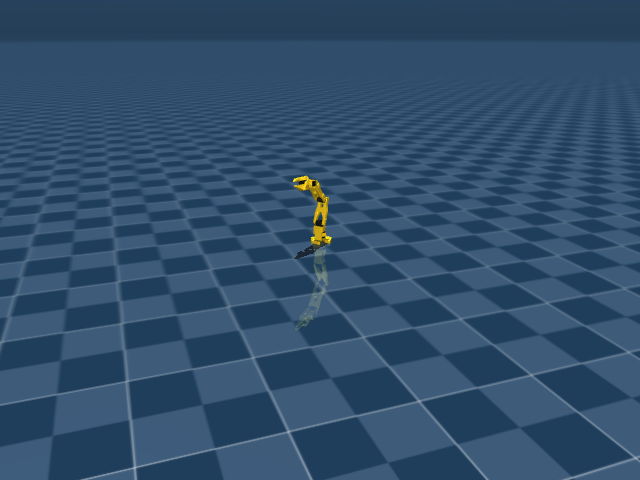

In [18]:
import mujoco

# Load model and create data structure
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model) #data structure to hold simulation state (joint positions, velocities, etc.)

# In the MJCF, the end-effector body corresponding to URDF's "gripper_link"
# is named "gripper" (see the body name="gripper" block in so101_new_calib.xml).
ee_body_name = "gripper"
ee_body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, ee_body_name)
if ee_body_id < 0:
    raise RuntimeError(f"MuJoCo body '{ee_body_name}' not found in model; check the XML for the correct name.")
print(f"End-effector body id in MuJoCo: {ee_body_id}")

# Forward kinematics for SO-Arm 101 using MuJoCo
def fk_so101_mujoco(theta):
    """Forward kinematics for SO-Arm 101 using MuJoCo.

    Parameters
    ----------
    theta : array_like, shape (5,)
        Joint angles [θ1, θ2, θ3, θ4, θ5] in radians,
        ordered as in fk_so101_poe.
    """
    theta = np.asarray(theta, dtype=float).flatten()
    if theta.size != 5:
        raise ValueError("theta must contain 5 joint angles: [θ1, θ2, θ3, θ4, θ5].")

    # Reset joint positions and set the first 5 DOFs
    data.qpos[:] = 0.0
    data.qpos[:5] = theta

    # Run forward kinematics
    mujoco.mj_forward(model, data)

    # Extract pose of gripper (same frame used for POE model) in world/base frame
    pos = data.xpos[ee_body_id].copy()                   # (3,)
    R_flat = data.xmat[ee_body_id].copy()                # length-9 row-major
    R = R_flat.reshape(3, 3)

    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = pos
    return T

# Example: compare MuJoCo FK with POE FK for the same joint angles
theta_compare = np.deg2rad([50, -20, -30, 40, -15])

T_poe = fk_so101_poe(theta_compare)
T_mjc = fk_so101_mujoco(theta_compare)

print("POE T(θ):")
print(np.round(T_poe, 4))
print("\nMuJoCo T(θ):")
print(np.round(T_mjc, 4))

# Position error
pos_err = np.linalg.norm(T_poe[:3, 3] - T_mjc[:3, 3])
print(f"\nPosition error (meters): {pos_err:.6e}")

# Orientation error (angle between rotations)
R_err = T_poe[:3, :3].T @ T_mjc[:3, :3]
_, angle_err, _ = matrix_log_so3(R_err)
print(f"Orientation error (degrees): {np.degrees(angle_err):.6e}")

# Render an image of the arm in the final MuJoCo configuration
renderer = mujoco.Renderer(model, height=480, width=640)
renderer.update_scene(data)

media.show_image(renderer.render())

### Task 3.3: Visualizing Motion from Home to a Target Configuration

In this subtask, you will generate a short **animation of the SO-Arm 101** moving from the home configuration (all joint angles = 0) to a chosen target configuration.

We will:
- Linearly interpolate the joint angles from home to a target vector.
- Use MuJoCo's **offscreen renderer** (no interactive viewer) to capture frames.
- Use Matplotlib's animation tools to display the motion directly in the notebook (works on Colab).

You can change the target joint angles to explore different motions and compare the final pose with the POE and MuJoCo FK results computed above.

In [ ]:
# MuJoCo visualization of motion from home to a target configuration

import numpy as np

# Helper: linear interpolation in joint space
def interpolate_trajectory(theta_start, theta_goal, num_steps=60):
    theta_start = np.asarray(theta_start, dtype=float).flatten()
    theta_goal = np.asarray(theta_goal, dtype=float).flatten()

    if theta_start.size != theta_goal.size:
        raise ValueError("theta_start and theta_goal must have the same length")
    return np.linspace(theta_start, theta_goal, num_steps)

# Define home and target joint configurations (5 DOF)
theta_home = np.zeros(5)

# Use the same target as in the FK comparison above; feel free to change
theta_target = theta_compare.copy()

traj = interpolate_trajectory(theta_home, theta_target, num_steps=60)

# Collect rendered frames for video
frames = []

# Simple brightness / contrast parameters
gamma = 0.8   # < 1 brightens mid-tones
gain = 1.4    # > 1 overall brightness scale

# Reset MuJoCo state and render trajectory using an offscreen renderer
mujoco.mj_resetData(model, data)

with mujoco.Renderer(model, height=480, width=640) as renderer:
    for q in traj:
        # Set the first 5 joint angles
        data.qpos[:] = 0.0
        data.qpos[:5] = q
        mujoco.mj_forward(model, data)

        # Render the current frame
        renderer.update_scene(data)
        img = renderer.render()  # RGB image as a NumPy array

        frames.append(img)

# Display video using mediapy (already installed and imported as media)
media.show_video(frames, fps=60)

This browser does not support the video tag.


## Task 4: Forward Velocity Kinematics

In this task, we practice how to solve the **forward velocity kinematics**, which relates joint velocities to end-effector linear and angular velocities through the **Jacobian matrix**. Specifically, given joint angle rates $\dot{\boldsymbol{\theta}}$, we compute the end-effector spatial velocity $\mathcal{V}_e = (\boldsymbol{\omega}_e, \mathbf{v}_e)$ using:

$$\mathcal{V}_e = \mathbf{J}(\boldsymbol{\theta}) \dot{\boldsymbol{\theta}}$$

where $\mathbf{J}(\boldsymbol{\theta})$ is the 6×n Jacobian matrix that depends on the current joint configuration. We will compute the Jacobian both analytically (using the Product of Exponentials and matrix derivatives) and verify it numerically through finite differences. This provides essential tools for velocity control, singularity analysis, and trajectory planning in robot manipulation.

### Task 4.1 Implementing a special case (Example 5.3 in textbook)

Example 5.3 in the Modern Robotics textbooks is about the space Jacobian for a RRPRRRR robotic arm. We have derived the space Jacobian in lectures. In this task, we will compute the specific Jacobian.

![image.png](attachment:image.png)

In [20]:
import numpy as np

# ============================================================================
# 1. ROTATION MATRIX FUNCTIONS
# ============================================================================

def rot_z(theta):
    """
    Rotation matrix about the z-axis by angle theta (in radians).

    Args:
        theta: Rotation angle in radians

    Returns:
        3x3 rotation matrix
    """
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ])

def rot_x(theta):
    """
    Rotation matrix about the x-axis by angle theta (in radians).

    Args:
        theta: Rotation angle in radians

    Returns:
        3x3 rotation matrix
    """
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [1,  0,  0],
        [0,  c, -s],
        [0,  s,  c]
    ])

def rot_y(theta):
    """
    Rotation matrix about the y-axis by angle theta (in radians).

    Args:
        theta: Rotation angle in radians

    Returns:
        3x3 rotation matrix
    """
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [ c, 0, s],
        [ 0, 1, 0],
        [-s, 0, c]
    ])

# ============================================================================
# 2. SPACE JACOBIAN CALCULATION FOR EXAMPLE 5.3 (RRPRRRR CHAIN)
# ============================================================================

def compute_space_jacobian_example53(theta):
    """
    Compute the space Jacobian for the RRPRRRR robotic arm in Example 5.3
    from the Modern Robotics textbook.

    The robot has:
    - Joint 1: Rotational about z-axis, anchor at base, q1 = (0, 0, L1)
    - Joint 2: Rotational, with axis depending on rotation by theta1
    - Joint 3: Prismatic joint
    - Joints 4-6: Rotational joints

    Link parameters:
    - L1: Height of base
    - L2: Length of upper arm

    Args:
        theta: Joint angle vector [θ1, θ2, θ3, θ4, θ5, θ6]
               where θ3 is the prismatic distance

    Returns:
        J: 6×6 space Jacobian matrix
    """
    # Define link parameters (adjust these according to your robot)
    L1 = 1.0    # Base height
    L2 = 1.0    # Upper arm length

    # Extract joint angles
    theta1, theta2, theta3, theta4, theta5, theta6 = theta

    # ========== Compute twist axes and joint positions ==========
    # Joint 1: First revolute joint (z-axis at base)
    omega_1 = np.array([0, 0, 1])
    q_1 = np.array([0, 0, 0])  # Axis passes through origin

    # Compute spatial twist for joint 1
    v_1 = np.cross(-omega_1, q_1)
    xi_1 = np.concatenate([omega_1, v_1])

    # ========== Joint 2: Second revolute joint ==========
    # Rotation about z-axis affected by theta1
    R01 = rot_z(theta1)

    # Second joint axis direction in base frame
    # From textbook: direction is (-c1, -s1, 0)
    omega_2_local = np.array([-1, 0, 0])  # In frame 1
    omega_2 = R01 @ omega_2_local
    q_2 = np.array([0, 0, L1])

    v_2 = np.cross(-omega_2, q_2)
    xi_2 = np.concatenate([omega_2, v_2])

    # ========== Joint 3: Prismatic joint ==========
    # The prismatic joint axis direction
    omega_3 = np.array([0, 0, 0])  # No rotation
    # Direction depends on the rotations from joints 1 and 2
    R02 = R01 @ rot_x(-theta2)
    d_3_local = np.array([0, 1, 0])  # Prismatic direction in frame 2
    d_3 = R02 @ d_3_local
    v_3 = d_3  # For prismatic joint

    xi_3 = np.concatenate([omega_3, v_3])

    # ========== Joints 4-6: Wrist revolute joints ==========
    # Wrist center position: q_w = [0, 0, L1] + Rot(z, θ1)Rot(x, -θ2)[0, L2+θ3, 0]
    q_w_base = np.array([0, 0, L1])
    q_w_offset_local = np.array([0, L2 + theta3, 0])
    q_w_pos = q_w_base + R02 @ q_w_offset_local

    # Joint 4
    R03 = R02
    omega_4_local = np.array([0, 0, 1])
    omega_4 = R03 @ omega_4_local

    v_4 = np.cross(-omega_4, q_w_pos)
    xi_4 = np.concatenate([omega_4, v_4])

    # Joint 5
    R04 = R03 @ rot_z(theta4)
    omega_5_local = np.array([-1, 0, 0])
    omega_5 = R04 @ omega_5_local

    v_5 = np.cross(-omega_5, q_w_pos)
    xi_5 = np.concatenate([omega_5, v_5])

    # Joint 6
    R05 = R04 @ rot_x(-theta5)
    omega_6_local = np.array([0, 1, 0])
    omega_6 = R05 @ omega_6_local

    v_6 = np.cross(-omega_6, q_w_pos)
    xi_6 = np.concatenate([omega_6, v_6])

    # ========== Construct Space Jacobian ==========
    # Jacobian columns are the spatial twists
    J = np.column_stack([xi_1, xi_2, xi_3, xi_4, xi_5, xi_6])

    return J


# Define test joint angles (in radians)
test_theta = np.array([
    np.pi/4,      # theta1 (45 degrees)
    np.pi/6,      # theta2 (30 degrees)
    0.5,          # theta3 (prismatic displacement)
    0,            # theta4
    0,            # theta5
    0             # theta6
])

print(f"\nJoint angles (radians): {test_theta}")

# Method 1: Specific implementation
J_specific = compute_space_jacobian_example53(test_theta)
print(f"\n--- Method 1: Specific Implementation (compute_space_jacobian_example53) ---")
print("Space Jacobian J:")
print(np.round(J_specific, 4))


Joint angles (radians): [0.785 0.524 0.5   0.    0.    0.   ]

--- Method 1: Specific Implementation (compute_space_jacobian_example53) ---
Space Jacobian J:
[[ 0.    -0.707  0.    -0.354 -0.707 -0.612]
 [ 0.    -0.707  0.     0.354 -0.707  0.612]
 [ 1.     0.     0.     0.866  0.    -0.5  ]
 [ 0.     0.707 -0.612  0.707  0.177 -0.612]
 [ 0.    -0.707  0.612  0.707 -0.177 -0.612]
 [ 0.     0.    -0.5    0.     1.299  0.   ]]


### Task 4.2 General implementation of Jacobian for any given open-chain robotic arm

Now we can have a general approach to compute the Jacobian using the screw-based approach, and apply it to the SO-Arm 101.

For an $n$-joint serial chain, the **space twist** is related to joint rates by

$$
\mathcal{V}_s = J_s(\theta)\,\dot{\theta}, \qquad J_s(\theta)\in\mathbb{R}^{6\times n},\ \dot{\theta}\in\mathbb{R}^{n}.
$$

The columns of the space Jacobian are

$$
J_{s1}(\theta)=S_1,
$$

and for $i=2,\dots,n$,

$$
J_{si}(\theta)
=\operatorname{Ad}_{\,e^{[S_1]\theta_1}e^{[S_2]\theta_2}\cdots e^{[S_{i-1}]\theta_{i-1}}}S_i.
$$

This is exactly what `compute_space_jacobian_screw(theta, S_list)` in the next cell does:

- Initialize $J_s[:,0]=S_1$.
- Build the cumulative transform
  $$
  T_{i-1}=e^{[S_1]\theta_1}\cdots e^{[S_{i-1}]\theta_{i-1}}.
  $$
- Compute each column as
  $$
  J_s[:,i]=\operatorname{Ad}_{T_{i-1}}\,S_i.
  $$

With $T=\begin{bmatrix}R&p\\0&1\end{bmatrix}$, the adjoint used in the code is

$$
\operatorname{Ad}_T=
\begin{bmatrix}
R & 0\\
[p]R & R
\end{bmatrix},
$$

where $[p]$ is the skew-symmetric matrix of $p$.

> Index note: the equation above uses $i=2\ldots n$ (1-based math indexing), while Python loops over `i=1...n-1` (0-based indexing).

In [21]:
# ============================================================================
# GENERAL SPACE JACOBIAN USING SCREW-BASED POE APPROACH
# ============================================================================

def adjoint_transformation(T):
    """
    Compute the adjoint transformation [Ad_T] for a homogeneous matrix T.

    For T = [[R, p], [0, 1]], the adjoint is:
    [Ad_T] = [[R,        0    ],
              [[p]R,     R    ]]

    where [p] is the skew-symmetric matrix of p.

    Parameters:
    T: 4x4 homogeneous transformation matrix

    Returns:
    Ad_T: 6x6 adjoint transformation matrix
    """
    R = T[:3, :3]
    p = T[:3, 3]

    # Create skew-symmetric matrix of p
    p_skew = skew_symmetric(p)

    # Construct adjoint matrix
    Ad_T = np.zeros((6, 6))
    Ad_T[:3, :3] = R
    Ad_T[3:, :3] = p_skew @ R
    Ad_T[3:, 3:] = R

    return Ad_T


def compute_space_jacobian_screw(theta, S_list):
    """
    General function to compute space Jacobian for any serial chain robot
    using the pure screw-based POE approach.

    This is the PURE screw theory method:
    - All screw axes S_i are defined in the SPACE FRAME at home configuration
    - The Jacobian is computed using adjoint transformations

    The space Jacobian columns are:
    - J_s[:, 0] = S_1
    - J_s[:, i] = [Ad_{exp([S_1]θ_1)...exp([S_{i-1}]θ_{i-1})}] S_i  for i > 0

    Parameters:
    -----------
    theta : array_like, shape (n,)
        Joint angles/displacements [θ1, θ2, ..., θn]

    S_list : array_like, shape (6, n) or list of n 6D arrays
        Space-frame screw axes at home configuration.
        Each column (or list element) is a 6D screw: [ω; v]
        - For revolute joints: ω is rotation axis, v = -ω × q
        - For prismatic joints: ω = 0, v is translation direction

    Returns:
    --------
    J_s : ndarray, shape (6, n)
        Space Jacobian matrix
        Each column represents the instantaneous twist caused by unit velocity
        at the corresponding joint, expressed in the space frame.

    Example:
    --------
    >>> # For a 3-DOF robot with screw axes S1, S2, S3
    >>> S_list = np.column_stack([S1, S2, S3])  # 6x3 matrix
    >>> theta = np.array([0.1, 0.2, 0.3])
    >>> J = compute_space_jacobian_screw(theta, S_list)
    """
    # Convert inputs to numpy arrays
    theta = np.asarray(theta).flatten()

    # Handle S_list as either 6×n array or list of n 6D vectors
    if isinstance(S_list, list):
        S_list = np.column_stack(S_list)
    else:
        S_list = np.asarray(S_list)

    # Get number of joints
    n_joints = S_list.shape[1]

    # Verify dimensions
    if theta.size != n_joints:
        raise ValueError(f"theta has {theta.size} elements but S_list has {n_joints} screw axes")
    if S_list.shape[0] != 6:
        raise ValueError(f"Each screw axis must be 6D, but S_list has shape {S_list.shape}")

    # Initialize Jacobian
    J_s = np.zeros((6, n_joints))

    # First column: J_1 = S_1 (no transformation needed at identity)
    J_s[:, 0] = S_list[:, 0]

    if n_joints == 1:
        return J_s

    # Cumulative transformation T = I initially
    T_cumulative = np.eye(4)

    # Compute subsequent columns using adjoint transformations
    for i in range(1, n_joints):
        # Update cumulative transformation: T = T @ exp([S_{i-1}]θ_{i-1})
        S_prev = S_list[:, i-1]
        theta_prev = theta[i-1]
        T_exp = matrix_exp_se3(S_prev, theta_prev)
        T_cumulative = T_cumulative @ T_exp

        # Compute adjoint transformation [Ad_T]
        Ad_T = adjoint_transformation(T_cumulative)

        # Transform the screw axis from space frame to current configuration
        # J_i = [Ad_T] S_i
        S_i = S_list[:, i]
        J_s[:, i] = Ad_T @ S_i

    return J_s


# ============================================================================
# TEST: Compare general screw method with specific implementations
# ============================================================================

print("=" * 70)
print("Testing General Screw-Based Jacobian Function")
print("=" * 70)

# Test 1: Verify with SO-ARM 101
print("\n--- Test 1: SO-ARM 101 ---")
theta_test = np.deg2rad([30, -20, 15, -10, 45])


# Using general screw function
J_SO101 = compute_space_jacobian_screw(theta_test, S_list_SO101)

print(f"Joint angles (deg): {np.rad2deg(theta_test)}")
print(f"\nUsing general screw function:")
print(np.round(J_SO101, 4))

Testing General Screw-Based Jacobian Function

--- Test 1: SO-ARM 101 ---
Joint angles (deg): [ 30. -20.  15. -10.  45.]

Using general screw function:
[[-0.     0.5    0.5    0.5   -0.837]
 [ 0.     0.866  0.866  0.866  0.483]
 [-1.     0.     0.     0.    -0.259]
 [-0.    -0.101 -0.201 -0.216 -0.101]
 [ 0.039  0.058  0.116  0.124 -0.164]
 [ 0.     0.064  0.052  0.186  0.019]]


## Lab2 Problems



**Problem 1.** Implement the forward position kinematics for the 6R robot (Example 4.3) in Modern Robotics textbook using the POE method in Task 1. Assume $L=1$.

Test with three configurations: (a) all joints at zero, (b) θ = [30°, -45°, 60°, -30°, 45°, -60°], and (c) θ = [90°, 0°, -90°, 45°, -45°, 0°].
![alt text](image.png)

**Problem 2.** Solving the forward position kinematics for UR5e Robot

Load the **UR5e** model from MuJoCo Menagerie (I have provided some sample code to do this) and implement **MuJoCo-based forward kinematics only** (similar workflow to Task 3.2). [UR5e MuJoCo Model](https://github.com/google-deepmind/mujoco_menagerie/tree/main/universal_robots_ur5e)

![alt text](https://github.com/google-deepmind/mujoco_menagerie/blob/main/universal_robots_ur5e/ur5e.png)

Your task:
1. Load the UR5e model with `mujoco.MjModel.from_xml_path(...)` and create `MjData`.
2. Write a function `fk_ur5e_mujoco(theta)` that:
    - takes a 6×1 joint vector (radians),
    - sets `data.qpos[:6] = theta`,
    - calls `mujoco.mj_forward(...)`,
    - returns a 4×4 homogeneous transform of the end-effector (choose one body/site frame and state it clearly).
3. Test and report the end-effector pose for these configurations (degrees):
    - **Config A (home):** `[0, 0, 0, 0, 0, 0]`
    - **Config B:** `[30, -45, 60, -30, 45, -60]`
    - **Config C:** `[90, 0, -90, 45, -45, 0]`
4. For each test, print:
    - the joint vector (rad),
    - the resulting \(T \in SE(3)\) (rounded),

In [22]:
import os, subprocess
import numpy as np

# Download UR5e model from MuJoCo Menagerie (Google DeepMind)
# NOTE: Use the git repository URL, not the /tree/... webpage URL
REPO_URL = "https://github.com/google-deepmind/mujoco_menagerie.git"
MODEL_SUBDIR = "universal_robots_ur5e"

# Use a Colab-friendly base directory when available, otherwise local folder
if os.path.exists("/content"):
    BASE_MODEL_DIR = "/content/mujoco_models"
else:
    BASE_MODEL_DIR = os.path.join(os.getcwd(), "mujoco_models")

os.makedirs(BASE_MODEL_DIR, exist_ok=True)
REPO_DIR = os.path.join(BASE_MODEL_DIR, "mujoco_menagerie")

if not os.path.exists(REPO_DIR):
    print("Cloning MuJoCo Menagerie repository...")
    subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR])
else:
    print("MuJoCo Menagerie repository already present.")

UR5E_DIR = os.path.join(REPO_DIR, MODEL_SUBDIR)

# Most menagerie robot folders provide a scene.xml entry point
xml_path = os.path.join(UR5E_DIR, "scene.xml")

print("UR5e model directory:")
print(UR5E_DIR)
print("\nUR5e MuJoCo XML:")
print(xml_path)
print(f"\nExists: {os.path.exists(xml_path)}")

# Optional: list files so students can inspect the model package
if os.path.exists(UR5E_DIR):
    print("\nFiles in UR5e folder:")
    for name in sorted(os.listdir(UR5E_DIR)):
        print(" -", name)

# ---------------------------------------------------------------------------
# Student task (leave for students):
# 1) Load the UR5e model with MuJoCo
# 2) Implement UR5e forward kinematics using MuJoCo
# ---------------------------------------------------------------------------

Cloning MuJoCo Menagerie repository...
UR5e model directory:
/content/mujoco_models/mujoco_menagerie/universal_robots_ur5e

UR5e MuJoCo XML:
/content/mujoco_models/mujoco_menagerie/universal_robots_ur5e/scene.xml

Exists: True

Files in UR5e folder:
 - CHANGELOG.md
 - LICENSE
 - README.md
 - assets
 - scene.xml
 - ur5e.png
 - ur5e.xml


**Problem 3.** Using the general screw-based method in Task 4.2 to compute the Jacobian for the 6R robot in example 4.3 of Modern Robotics Textbook. Figure is the same as in Problem 1. Assume $L=1$.

Test your solution with three configurations: (a) all joints at zero, (b) θ = [30°, -45°, 60°, -30°, 45°, -60°], and (c) θ = [90°, 0°, -90°, 45°, -45°, 0°].